## DECISION TREE

### 1. Data Preparation:

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [39]:
df=pd.read_excel('heart_disease.xlsx',sheet_name=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [40]:
df.shape

(908, 13)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


### 2. Exploratory Data Analysis (EDA):

In [42]:
## missing value
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [43]:
df.fillna({'oldpeak':df.oldpeak.median()},inplace=True)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [44]:
## duplicates
df.duplicated().sum()

np.int64(1)

In [45]:
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

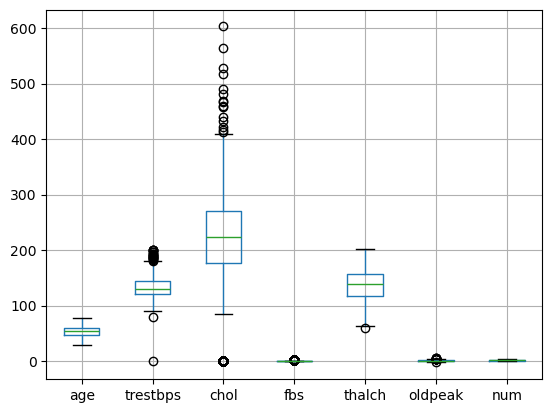

In [46]:
## outliers
df.boxplot()
plt.show()

In [47]:
## outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR =Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

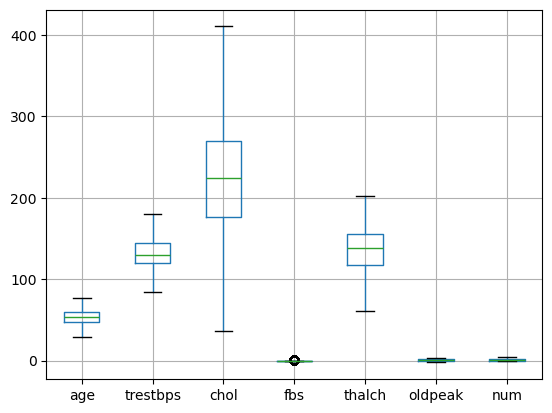

In [48]:
df.boxplot()
plt.show()

In [49]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,53.787211,133.264609,207.232359,135.977949,0.855788,1.007718
std,9.162016,19.303104,97.148377,26.809967,1.024909,1.144594
min,29.000000,84.000000,36.250000,61.000000,-2.250000,0.000000
25%,47.500000,120.000000,176.500000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,180.000000,410.250000,202.000000,3.750000,4.000000


In [50]:
## chol value less than 60 impossible
df = df[df['chol'] >= 50]

In [51]:
## oldpeak cant be less than 0
df['oldpeak'] = df['oldpeak'].clip(lower=0)

In [52]:
cat_cols = df.select_dtypes(include=['object','bool']).columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [53]:
## inconsistency

In [54]:
## fix spaces in cat_col
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

In [55]:
## data type inconsistency
for col in df.columns:
    type_counts = df[col].apply(type).value_counts()
    if len(type_counts) > 1:
        print(f"\nInconsistency found in column: {col}")
        print(type_counts)

In [56]:
## unique values in cat cols
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())


sex:
['Male' 'Female']

cp:
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']

fbs:
['True' 'False']

restecg:
['lv hypertrophy' 'normal' 'st-t abnormality']

exang:
['False' 'True' 'FALSE' 'TURE']

slope:
['downsloping' 'flat' 'upsloping']

thal:
['fixed defect' 'normal' 'reversable defect']


In [57]:
# Fix inconsistent True/False values
df['exang'] = df['exang'].astype(str).str.strip().str.upper()

df['exang'] = df['exang'].replace({
    'TRUE': 'True',
    'FALSE': 'False',
    'TURE': 'True'     
})

In [58]:
df['exang'].unique()

array(['False', 'True'], dtype=object)

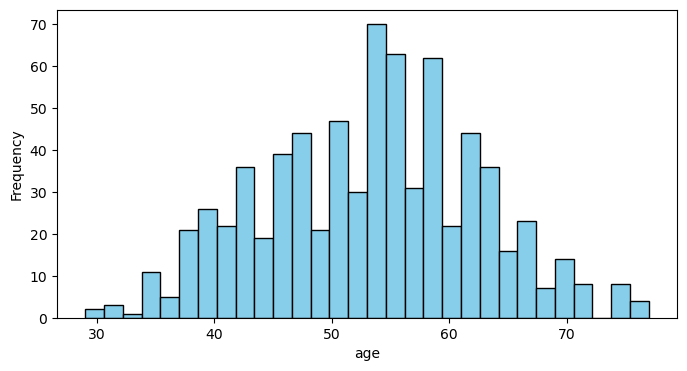

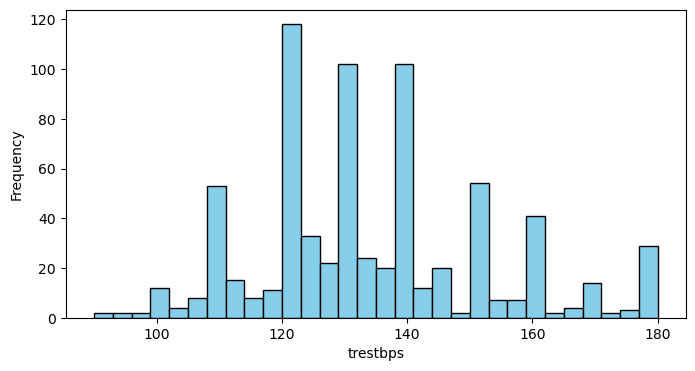

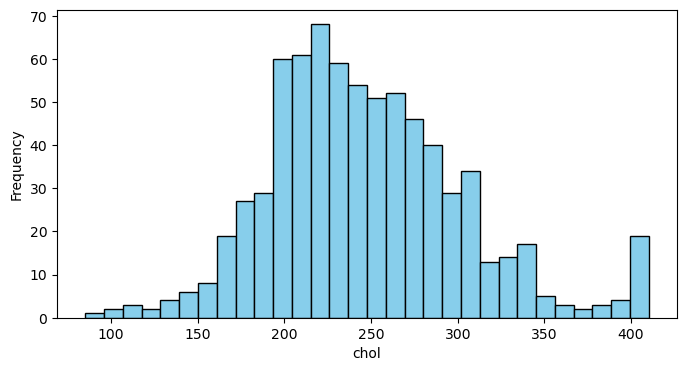

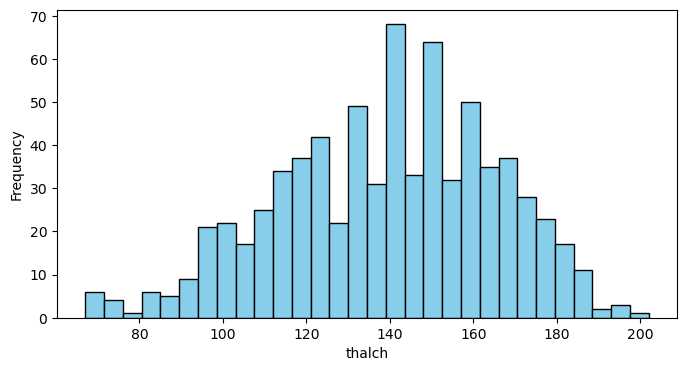

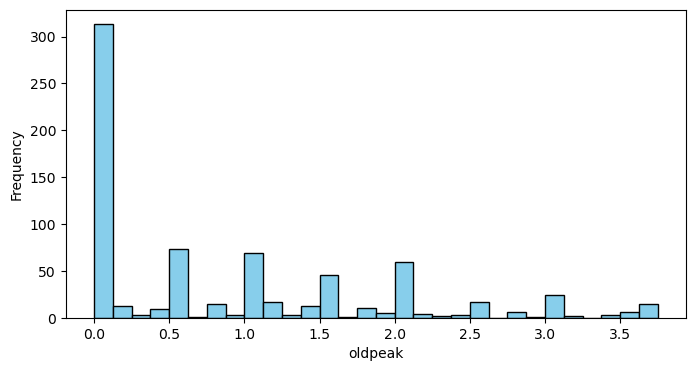

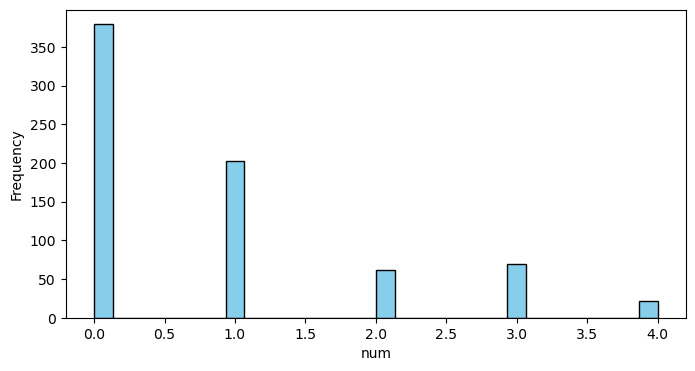

In [59]:
## histogram
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

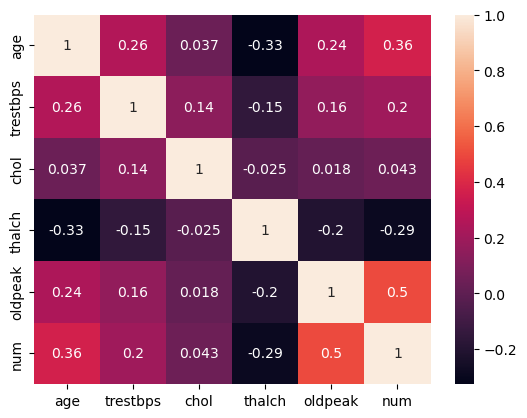

In [60]:
corr=df[num_cols].corr()
sns.heatmap(corr,annot=True)
plt.show()

### 3. Feature Engineering:

In [61]:
target=df['num']
features=df.drop(columns=['num'])

In [62]:
## label encoding
lab_enc=LabelEncoder()
for col in ['sex', 'fbs', 'exang']:
    features[col] = lab_enc.fit_transform(features[col])

In [63]:
# get_dummies
features = pd.get_dummies(features, columns=['cp','restecg','slope','thal'],dtype='int', drop_first=True)

In [64]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak'] 

In [65]:
## a.Standard Scaling
std_sca=StandardScaler()
features[num_cols]=std_sca.fit_transform(features[num_cols])

In [66]:
features.shape

(735, 17)

### 4. Decision Tree Classification:

In [67]:
## train_test split
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(588, 17)
(147, 17)
(588,)
(147,)


In [99]:
dec_tree=DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=4,min_samples_split=2,min_samples_leaf=2)
dec_tree.fit(x_train,y_train)
y_pred=dec_tree.predict(x_test)
y_pred_prob = dec_tree.predict_proba(x_test)
accuracy_score(y_test,y_pred)

0.5782312925170068

In [98]:
 from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

In [70]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.68      0.68        76
           1       0.75      0.07      0.13        41
           2       0.09      0.25      0.14        12
           3       0.06      0.07      0.06        14
           4       0.06      0.25      0.09         4

    accuracy                           0.41       147
   macro avg       0.33      0.27      0.22       147
weighted avg       0.58      0.41      0.41       147



In [74]:
precision = precision_score(y_test, y_pred,zero_division=0, average='macro')  
recall    = recall_score(y_test, y_pred,zero_division=0, average='macro')
f1        = f1_score(y_test, y_pred,zero_division=0, average='macro')
roc_auc = roc_auc_score(y_test, y_pred_prob,multi_class='ovo')
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Precision: 0.3284679222566219
Recall   : 0.26576196589033557
F1-Score : 0.2218665431908216
ROC-AUC  : 0.5680280159239562


### 5. Hyperparameter Tuning:

In [75]:
## using gridsearch
paramas={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,8),'min_samples_split': [2, 5, 10, 15, 20]}

In [82]:
grid_search=GridSearchCV(dec_tree,paramas,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 2,
 'min_samples_split': 2,
 'splitter': 'random'}

In [107]:
dec_tree=DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=2,min_samples_split=2)
dec_tree.fit(x_train,y_train)
y_pred=dec_tree.predict(x_test)
y_pred_prob = dec_tree.predict_proba(x_test)
accuracy_score(y_test,y_pred)

0.5918367346938775

### 6. Model Evaluation and Analysis:

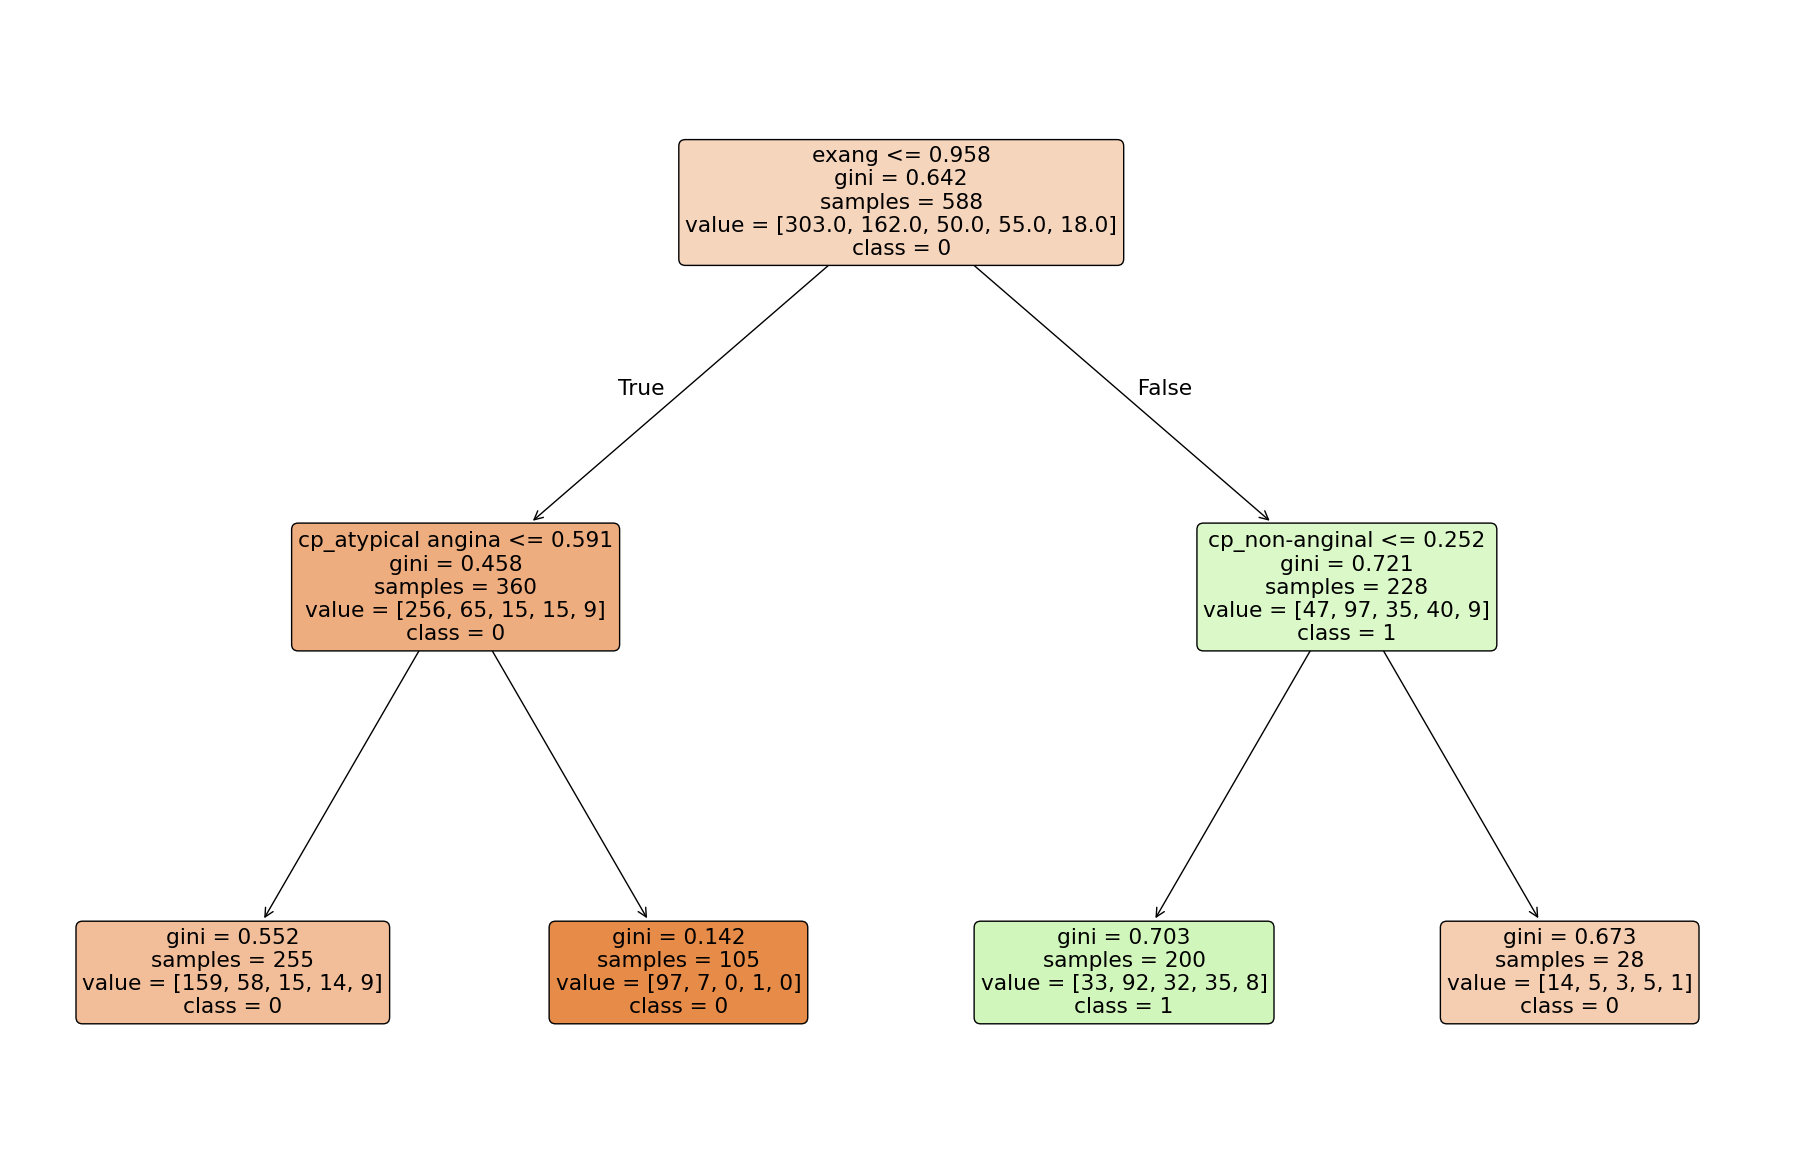

In [108]:
## Decision tree visualization
plt.figure(figsize=(23,15))
plot_tree(dec_tree,
          filled=True,
          feature_names=features.columns,
          class_names=[str(c) for c in target.unique()],
          rounded=True)
plt.show()

### Interview Questions:

##### 1. What are some common hyperparameters of decision tree models, and how do they affect themodel's performance?

##### 2. What is the difference between the Label encoding and One-hot encoding?